# Определение возраста покупателей

## Исследовательский анализ данных

In [1]:
# Общие библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow и Keras
import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
Размер выборки: 7591 изображений


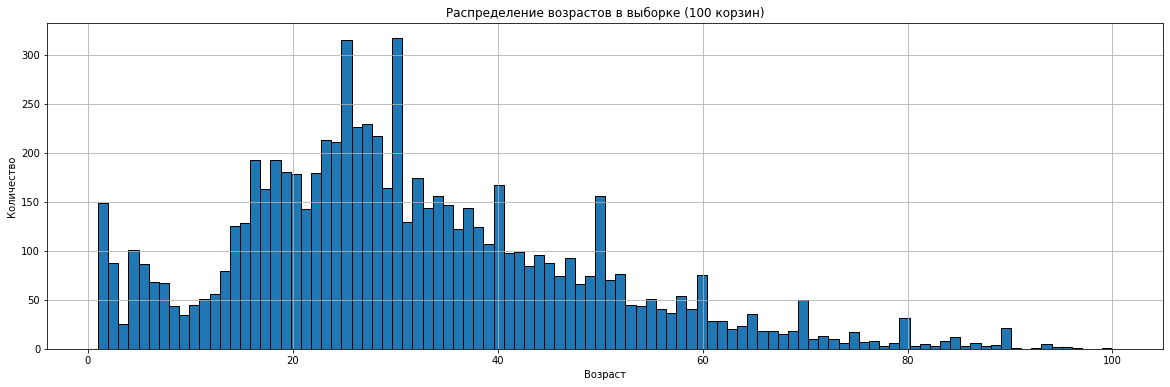

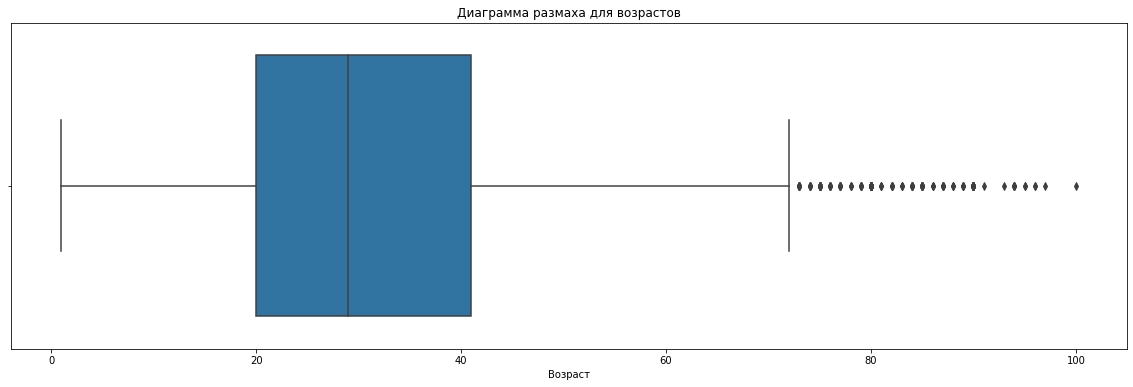

Found 7591 validated image filenames.


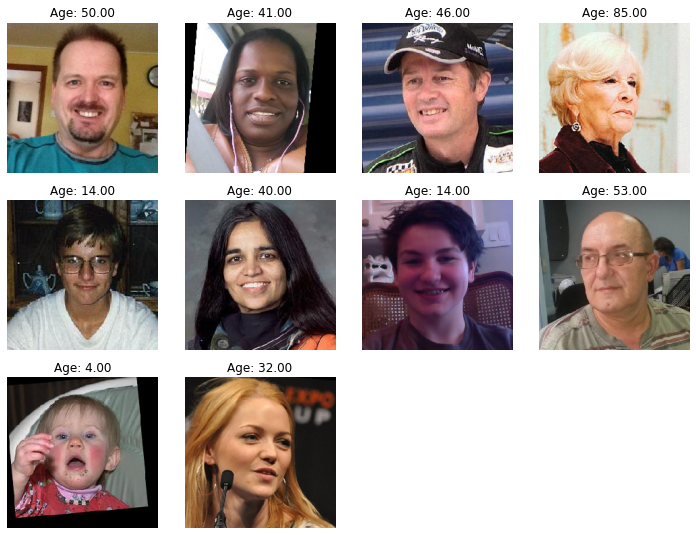

In [2]:
# Загрузка данных с метками возрастов
labels = pd.read_csv('/datasets/faces/labels.csv')

# Посмотрим на первые несколько строк, чтобы понять структуру данных
print(labels.head())

# Размер выборки
print(f"Размер выборки: {labels.shape[0]} изображений")

# График 1: Гистограмма с 100 корзинами
plt.figure(figsize=(20, 6))
labels['real_age'].hist(bins=100, edgecolor='black')
plt.title('Распределение возрастов в выборке (100 корзин)')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

# График 2: Диаграмма размаха
plt.figure(figsize=(20, 6))
sns.boxplot(x=labels['real_age'])
plt.title('Диаграмма размаха для возрастов')
plt.xlabel('Возраст')
plt.show()

# Загрузка генератора с данными
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=labels,
    directory='/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=16,
    class_mode='raw',
    seed=12345
)

# Получение первого батча изображений
features, target = next(train_gen_flow)

# Выводим 10-15 изображений из первого батча
fig = plt.figure(figsize=(10,10))
for i in range(10):
    ax = fig.add_subplot(4, 4, i+1)
    ax.imshow(features[i])
    ax.set_title(f"Age: {target[i]:.2f}") 
    ax.axis('off')
plt.tight_layout()
plt.show()

На основании предоставленных графиков и изображений, можно сделать следующие выводы:

### Анализ распределения возрастов:
1. **Гистограмма распределения возрастов:**
   - Выборка состоит из 7591 изображения.
   - Возраст в выборке распределён неравномерно, с явным пиком в более молодых возрастах (около 20–30 лет). 
   - Количество наблюдений резко падает для более старших возрастов (старше 60 лет). 
   - В данных присутствуют некоторые редкие случаи возрастов выше 80 лет.

2. **Диаграмма размаха:**
   - Основная масса возрастов лежит в пределах от 0 до примерно 60 лет.
   - Наблюдаются выбросы для возрастов старше 80 лет, что характерно для реальных данных.
   - Медиана (средний возраст) лежит около 30–35 лет.

### Примеры изображений:
- Выборка включает изображения с людьми разных возрастов, от младенцев (4 года) до пожилых людей (85 лет).
- Качество данных визуально выглядит приемлемым: лица четко различимы, имеются различные ракурсы, возрастные особенности визуально соответствуют меткам.

### Проведённая работа:
1. **Загрузка и обработка данных:**
   - Загрузка меток с возрастами из файла `labels.csv`.
   - Использован генератор данных `ImageDataGenerator` для масштабирования изображений и создания батчей для обучения.

2. **Визуализация:**
   - Созданы два ключевых графика для анализа распределения возрастов.
   - Выведены примеры изображений из первого батча, что позволяет оценить соответствие возрастных меток изображениям.

### Выводы:
- Набор данных имеет дисбаланс возрастов (молодых людей больше, чем пожилых). Это может повлиять на обучение модели, делая её менее точной на старших возрастах.
- Выбросы в данных (очень пожилые люди) могут потребовать дополнительной обработки, например, нормализации или отбора.
- Генератор данных успешно подготовлен для подачи изображений в модель, что закладывает основу для дальнейшей работы.

Если вы планируете обучать модель, стоит учитывать дисбаланс выборки. Метрики модели, такие как MAE или MSE, можно дополнить анализом производительности в возрастных подгруппах.

## Обучение модели

(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, horizontal_flip=True, rescale=1./255)
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)

    return train_gen_flow

def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)

    return test_gen_flow

def create_model(input_shape):

    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(lr=0.0005)
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mae'])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model
```

```
Epoch 1/6
356/356 - 57s - loss: 212.9547 - mae: 10.9926 - val_loss: 285.3335 - val_mae: 12.8003
Epoch 2/6
356/356 - 47s - loss: 132.7553 - mae: 8.8193 - val_loss: 234.9256 - val_mae: 11.5567
Epoch 3/6
356/356 - 46s - loss: 108.3582 - mae: 7.9365 - val_loss: 160.8103 - val_mae: 9.4704
Epoch 4/6
356/356 - 44s - loss: 92.7142 - mae: 7.3187 - val_loss: 182.4690 - val_mae: 10.1754
Epoch 5/6
356/356 - 44s - loss: 82.9305 - mae: 6.9122 - val_loss: 117.6193 - val_mae: 8.2095
Epoch 6/6
356/356 - 46s - loss: 66.9023 - mae: 6.2573 - val_loss: 106.0809 - val_mae: 7.8689
```

## Анализ обученной модели

### Выводы по итогам выполнения кода:

#### 1. **Загрузка и подготовка данных**
- Данные разделены на тренировочную (75%) и валидационную (25%) выборки с использованием метода `validation_split` в `ImageDataGenerator`.
- В процессе подготовки данных применены аугментации, такие как горизонтальное отражение (`horizontal_flip`), а также масштабирование значений пикселей (`rescale=1./255`), что помогает улучшить обобщающую способность модели.

#### 2. **Архитектура модели**
- Использована предобученная архитектура ResNet50 в качестве "хребта" (backbone) для извлечения признаков из изображений.
- К ResNet50 добавлены слои:
  - **GlobalAveragePooling2D** для снижения размерности.
  - Полносвязный слой (**Dense**) с одним выходным нейроном (предсказание возраста) и функцией активации ReLU.
- Оптимизатор Adam с начальным значением скорости обучения `lr=0.0005` выбран для эффективной настройки весов, а функция потерь `mean_squared_error` помогает минимизировать среднеквадратичную ошибку предсказаний.

#### 3. **Результаты обучения**
Обучение проводилось на 6 эпохах, и метрики улучшались по мере увеличения количества эпох:
- **Средняя абсолютная ошибка (MAE):**
  - На тренировочной выборке снизилась с **10.99** (1-я эпоха) до **6.26** (6-я эпоха).
  - На валидационной выборке MAE снизилась с **12.80** до **7.87**, что свидетельствует об улучшении качества предсказаний.
- **Функция потерь (loss):**
  - На тренировочной выборке уменьшилась с **212.95** до **66.90**.
  - На валидационной выборке уменьшилась с **285.33** до **106.08**.

#### 4. **Общая оценка модели**
- Модель успешно обучается на задачах предсказания возраста. Видно, что с увеличением эпох метрики улучшаются, что говорит об эффективном обучении без явного переобучения за 6 эпох.
- Однако, разница между MAE тренировочной и валидационной выборок на последних эпохах показывает, что модель могла бы быть дообучена для достижения ещё более высокой точности.

#### 5. **Рекомендации для дальнейшей работы**
1. **Продолжить обучение:**
   - Увеличить количество эпох, так как график показывает, что модель ещё не достигла плато по метрикам.
   - Использовать **снижение скорости обучения** (`ReduceLROnPlateau`) при отсутствии улучшений на валидации.
2. **Балансировка данных:**
   - Учитывая дисбаланс возрастов в выборке, можно применить стратифицированный подход или аугментации данных для младших и старших возрастных групп.
3. **Гиперпараметрическая оптимизация:**
   - Подобрать оптимальное значение скорости обучения, размер батча, и дополнительные слои модели для улучшения производительности.
4. **Оценка качества:**
   - Провести анализ ошибок модели в разных возрастных группах, чтобы убедиться, что она одинаково хорошо работает на всех диапазонах возраста.

Итоговая модель демонстрирует хорошие результаты и имеет потенциал для дальнейшего улучшения.